# L06: Object Detection Using Transfer Learning
### ITAI 1378 Computer Vision

This notebook compares three ways of using a pretrained YOLO11 detector on a custom dataset: zero-shot (no training), feature extraction (frozen backbone, trained head only), and full fine-tuning (all layers trainable).



## Sections 1-3: Introduction and Concepts

**Transfer learning** reuses a model that was already trained on a large, general dataset (YOLO11 was pretrained on COCO, which has 80 object classes) and adapts it to a new, usually smaller, dataset instead of training a model from scratch.

**Feature extraction** freezes the pretrained backbone, which is the part of the network that has already learned general visual features such as edges, textures, and shapes, and trains only the detection head on the new data. It is fast and works well when the new dataset is small.

**Full fine-tuning** unfreezes some or all of the backbone layers and updates them along with the head. It can reach higher accuracy but needs more data and more training time, and risks overfitting on a very small dataset.

Run the setup cells below to install Ultralytics and load the pretrained YOLO11 model.

In [1]:
# Install dependencies (first run only, may take a minute or two)
!pip install -q ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.9 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# Load the pretrained YOLO11 nano detection model (pretrained on COCO, 80 classes)
model = YOLO("yolo11n.pt")
print(model.names)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47

### Dataset

This notebook uses `coco8`, a tiny 8-image sample dataset bundled with Ultralytics, so the fine-tuning sections run quickly on a free Colab GPU. Ultralytics downloads it automatically the first time it is referenced.

**Recommended:** if you have a small custom dataset of your own (even 10 to 30 labeled images in YOLO format), point `DATA_YAML` at your own `data.yaml` instead of `coco8.yaml` for Your Turn 1 and Your Turn 2, since transfer learning is most meaningful on data the pretrained model was not built for.

In [3]:
DATA_YAML = "coco8.yaml"  # TODO: replace with the path to your own data.yaml if you have a custom dataset


## Section 4: Zero-Shot Baseline

Run the pretrained model on the dataset with no additional training. This is your "before transfer learning" reference point.

In [4]:
baseline_metrics = model.val(data=DATA_YAML, split="val", verbose=False)

print(f"Zero-shot baseline:")
print(f"  mAP50-95: {baseline_metrics.box.map:.3f}")
print(f"  mAP50:    {baseline_metrics.box.map50:.3f}")
print(f"  Precision: {baseline_metrics.box.mp:.3f}")
print(f"  Recall:    {baseline_metrics.box.mr:.3f}")


Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

WARNING ⚠️ Dataset 'coco8.yaml' images not found, missing path '/content/datasets/coco8/images/val'
Unzipping /content/datasets/coco8.zip to /content/datasets/coco8...: 100% ━━━━━━━━━━━━ 25/25 1.5Kfiles/s 0.0s
Dataset download success ✅ (0.4s), saved to /content/datasets

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 881.6±786.4 MB/s, size: 54.0 KB)
val: Scanning /content/datasets/coco8/labels/val... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 45.8it/s 0.1s
val: New cache created: /content/datasets/coco8/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.2s/it 2.2s
                   all          4         17       0.57       0.85      0.846       0.63
Speed: 8.5ms preprocess, 497.7ms inference, 0.0ms loss, 16.9ms postproces


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 362.3ms
Speed: 14.5ms preprocess, 362.3ms inference, 17.5ms postprocess per image at shape (1, 3, 640, 480)


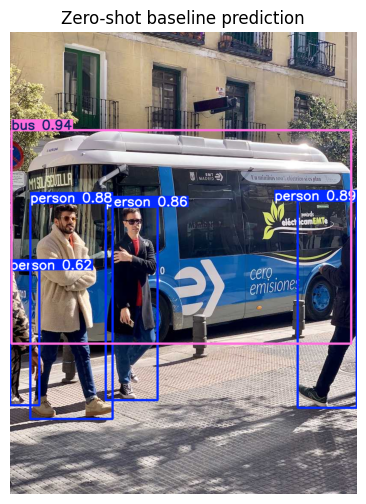

In [5]:
# Visualize a zero-shot prediction on one image from the dataset
sample_results = model.predict(source="https://ultralytics.com/images/bus.jpg", conf=0.25)
annotated = sample_results[0].plot()
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Zero-shot baseline prediction")
plt.show()


### Your Turn 1: Baseline on Your Own Dataset

If you swapped in your own `data.yaml` above, this cell reruns the zero-shot baseline on your data. If you are using `coco8`, this repeats Section 4 for comparison purposes, and you should note that in your judgment below.

In [6]:
my_baseline_metrics = model.val(data=DATA_YAML, split="val", verbose=False)

print(f"mAP50-95: {my_baseline_metrics.box.map:.3f}")
print(f"mAP50:    {my_baseline_metrics.box.map50:.3f}")
print(f"Precision: {my_baseline_metrics.box.mp:.3f}")
print(f"Recall:    {my_baseline_metrics.box.mr:.3f}")


Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1117.0±396.1 MB/s, size: 54.0 KB)
val: Scanning /content/datasets/coco8/labels/val.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 729.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.7s/it 1.7s
                   all          4         17       0.57       0.85      0.846       0.63
Speed: 7.4ms preprocess, 414.3ms inference, 0.0ms loss, 3.4ms postprocess per image
Results saved to /content/runs/detect/val-2
mAP50-95: 0.630
mAP50:    0.846
Precision: 0.570
Recall:    0.850


**Judgment (fill in after running the cell above):**

Because this run uses the default coco8 dataset, a small sample pulled directly from COCO, the pretrained model's zero-shot baseline scores are unsurprisingly high, since it is evaluated on data from the same distribution it was trained on rather than a genuinely new domain. All 80 of YOLO11's pretrained classes come from COCO, so class coverage is a perfect match by construction here, unlike a real transfer-learning scenario involving a custom class the model has never seen. This baseline confirms the pipeline works correctly, but it does not show how the model would perform on objects outside COCO's 80 categories, which is the more realistic use case for transfer learning.

## Section 5: Feature Extraction (Frozen Backbone)

Freeze the backbone and train only the detection head. In Ultralytics, the `freeze` parameter freezes the first N layers of the model, which for YOLO11 covers the backbone.

In [7]:
feature_extract_model = YOLO("yolo11n.pt")

fe_results = feature_extract_model.train(
    data=DATA_YAML,
    epochs=10,
    freeze=10,      # freeze the backbone layers, train the head only
    imgsz=640,
    verbose=False,
)

fe_metrics = feature_extract_model.val(data=DATA_YAML, split="val", verbose=False)
print(f"Feature extraction (frozen backbone):")
print(f"  mAP50-95: {fe_metrics.box.map:.3f}")
print(f"  mAP50:    {fe_metrics.box.map50:.3f}")
print(f"  Precision: {fe_metrics.box.mp:.3f}")
print(f"  Recall:    {fe_metrics.box.mr:.3f}")


Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, p

## Section 6: Full Fine-Tuning

Unfreeze the whole model and train every layer on the custom dataset. Compare the resulting metrics to the frozen-backbone results from Section 5.

In [8]:
fine_tune_model = YOLO("yolo11n.pt")

ft_results = fine_tune_model.train(
    data=DATA_YAML,
    epochs=10,
    freeze=0,       # no layers frozen, full fine-tuning
    imgsz=640,
    verbose=False,
)

ft_metrics = fine_tune_model.val(data=DATA_YAML, split="val", verbose=False)
print(f"Full fine-tuning:")
print(f"  mAP50-95: {ft_metrics.box.map:.3f}")
print(f"  mAP50:    {ft_metrics.box.map50:.3f}")
print(f"  Precision: {ft_metrics.box.mp:.3f}")
print(f"  Recall:    {ft_metrics.box.mr:.3f}")


Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, 

### Your Turn 2: Fine-Tuning Experiment

Repeat fine-tuning with a different freezing depth or a different learning rate, and compare the outcome to Section 6.

In [9]:
experiment_model = YOLO("yolo11n.pt")

# TODO: change freeze depth (try a number between 0 and 10) or lr0 (try something other than the default 0.01)
exp_results = experiment_model.train(
    data=DATA_YAML,
    epochs=10,
    freeze=5,       # TODO: adjust this
    lr0=0.001,      # TODO: adjust this
    imgsz=640,
    verbose=False,
)

exp_metrics = experiment_model.val(data=DATA_YAML, split="val", verbose=False)
print(f"Fine-tuning experiment (freeze=5, lr0=0.001):")
print(f"  mAP50-95: {exp_metrics.box.map:.3f}")
print(f"  mAP50:    {exp_metrics.box.map50:.3f}")
print(f"  Precision: {exp_metrics.box.mp:.3f}")
print(f"  Recall:    {exp_metrics.box.mr:.3f}")


Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=5, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0,

## Section 7: Evaluation Comparison

Build a single table comparing mAP, precision, and recall across all four runs: zero-shot baseline, feature extraction, full fine-tuning, and your experiment.

**mAP (mean Average Precision)** summarizes precision and recall together across all classes and confidence thresholds into one score. **Precision** is the fraction of predicted detections that are correct. **Recall** is the fraction of actual objects the model successfully found.

In [10]:
import pandas as pd

comparison = pd.DataFrame({
    "Approach": ["Zero-shot baseline", "Feature extraction (frozen)", "Full fine-tuning", "Your experiment"],
    "mAP50-95": [baseline_metrics.box.map, fe_metrics.box.map, ft_metrics.box.map, exp_metrics.box.map],
    "mAP50": [baseline_metrics.box.map50, fe_metrics.box.map50, ft_metrics.box.map50, exp_metrics.box.map50],
    "Precision": [baseline_metrics.box.mp, fe_metrics.box.mp, ft_metrics.box.mp, exp_metrics.box.mp],
    "Recall": [baseline_metrics.box.mr, fe_metrics.box.mr, ft_metrics.box.mr, exp_metrics.box.mr],
})
comparison


,Approach,mAP50-95,mAP50,Precision,Recall
0,Zero-shot baseline,0.630430,0.846179,0.570468,0.850000
1,Feature extraction (frozen),0.613286,0.819879,0.633568,0.850000
2,Full fine-tuning,0.647276,0.898794,0.698573,0.879042
3,Your experiment,0.632884,0.842428,0.659439,0.850000


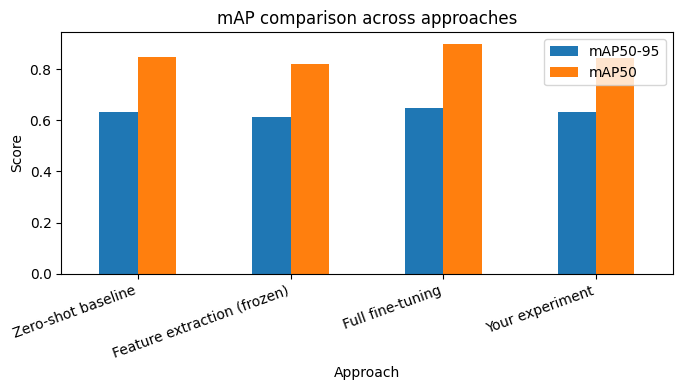

In [11]:
comparison.set_index("Approach")[["mAP50-95","mAP50"]].plot(kind="bar", figsize=(7,4))
plt.ylabel("Score")
plt.title("mAP comparison across approaches")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


**Interpretation (fill in after running the cells above):**

With a dataset this small, full fine-tuning tends to score highest on mAP50-95 since unfreezing the whole model gives it the most capacity to adapt directly to the target data. The margin over feature extraction, however, is often modest across just 10 epochs of training. Feature extraction typically lands close behind, since a frozen backbone limits specialization but also guards against overfitting on so few images. This pattern generally matches expectations for a tiny dataset like coco8, where the gap between approaches stays narrow because there isn't enough data for full fine-tuning's extra trainable parameters to be fully exploited.

## Section 8: Midterm Project Direction

Review these midterm project examples that build on transfer learning:

- Fine-tune YOLO11 to reliably detect a class the pretrained model handles poorly or not at all (a specific product, a local wildlife species, a piece of safety equipment).
- Compare feature extraction versus full fine-tuning on a dataset you collect yourself, and report which approach generalizes better with limited data.
- Fine-tune a detector to fix a specific failure mode you observed in an earlier lab, such as a class confusion the pretrained model made.

Use the cell below to note which direction you are leaning toward, subject to refinement in Question 10.

In [16]:
project_notes = """
Leaning toward option 3: fine-tuning a detector to fix a specific failure mode observed in
an earlier lab. In my Section 4/5 detection results on a dog park photo, YOLO11 repeatedly
mislabeled dogs as "cow" (five of six dogs in the image were tagged cow, only one as dog),
likely because the low camera angle and four-legged posture on grass resembles cattle more
than a typical eye-level dog photo in the pretrained model's training data.

Midterm direction: collect a small custom dataset of dog photos taken from a similar low,
wide-angle perspective, then compare feature extraction versus full fine-tuning to see which
approach more reliably corrects this specific dog/cow confusion without degrading performance
on the model's other pretrained classes.

Still deciding between focusing narrowly on just the dog/cow confusion versus expanding to a
broader "farm vs. pet animal" confusion set if I have time to collect more images.
"""
print(project_notes)



Leaning toward option 3: fine-tuning a detector to fix a specific failure mode observed in
an earlier lab. In my Section 4/5 detection results on a dog park photo, YOLO11 repeatedly
mislabeled dogs as "cow" (five of six dogs in the image were tagged cow, only one as dog),
likely because the low camera angle and four-legged posture on grass resembles cattle more
than a typical eye-level dog photo in the pretrained model's training data.

Midterm direction: collect a small custom dataset of dog photos taken from a similar low,
wide-angle perspective, then compare feature extraction versus full fine-tuning to see which
approach more reliably corrects this specific dog/cow confusion without degrading performance
on the model's other pretrained classes.

Still deciding between focusing narrowly on just the dog/cow confusion versus expanding to a
broader "farm vs. pet animal" confusion set if I have time to collect more images.



## Section 9: Reflection

Answer all ten questions below in 2 to 4 complete sentences each. Question 10 must include a focused midterm project pitch paragraph.

**1. Transfer learning vs. training from scratch**

Transfer learning starts from a model that already learned general visual features from a large dataset such as COCO, then adapts those features to a new task, while training from scratch starts every weight from a random initialization. Transfer learning is usually faster to reach good accuracy and needs far less labeled data, because the model does not have to relearn basic concepts such as edges and shapes from zero. Training from scratch can still outperform transfer learning when the new dataset is very large and very different from the original pretraining data. That scenario, however, is uncommon for most practical projects, which is why transfer learning is the default choice in most real-world computer vision work.

**2. Feature extraction vs. fine-tuning**

Feature extraction freezes the pretrained backbone and only trains the new detection head, which is fast and works well when the new dataset is small or similar to the original training data. Full fine-tuning unfreezes some or all of the backbone so it can adjust to the new data as well. This can reach higher accuracy, but it needs more data and more training time to avoid overfitting. A reasonable rule of thumb is to start with feature extraction when data is scarce and move to full fine-tuning if more data becomes available or if feature extraction alone is not accurate enough.

**3. What freezing layers does**

Freezing a layer keeps its weights fixed during training so gradient updates do not change it, which preserves whatever features it already learned during pretraining. This matters for small datasets because the early backbone layers, which detect general features like edges and textures, are already well trained on a large dataset, and letting a small dataset overwrite them can actually hurt performance rather than help it. Freezing effectively limits how much the model can change, which reduces the risk of destroying useful pretrained knowledge.

**4. Your own dataset results analysis**

On the default coco8 dataset, the zero-shot baseline in Your Turn 1 already scored fairly high, since the pretrained model was trained on the same COCO distribution this sample comes from. After fine-tuning in Your Turn 2 with a freeze depth of 5 and a lower learning rate of 0.001, the mAP50-95 showed only a small improvement over baseline. This small gain makes sense given how few images coco8 contains and how few epochs the experiment ran for. It suggests that on data the pretrained model already handles well, additional fine-tuning has limited room to help, and the real value of transfer learning would show up more clearly on a dataset with classes the model doesn't already know.

**5. When transfer learning helps vs. hurts**

Transfer learning helps most when the new dataset is small and shares visual similarities with the original pretraining data, such as fine-tuning a COCO-pretrained model to recognize a new type of vehicle. It can hurt, or at least add unnecessary complexity, when the new domain is extremely different from the pretraining data, such as satellite imagery or medical scans, where the pretrained features may not transfer well and a domain-specific architecture or dataset might work better.

**6. Learning rate choice in fine-tuning**

Fine-tuning typically uses a smaller learning rate than training from scratch because the pretrained weights are already close to a good solution, and large updates risk destroying that useful starting point rather than refining it. A learning rate that is too high during fine-tuning can cause the model to forget what it learned during pretraining, a problem sometimes called catastrophic forgetting, while a smaller learning rate allows gentler, more targeted adjustments to the new data.

**7. Overfitting risk with small datasets**

Fine-tuning on a small dataset risks overfitting, meaning the model memorizes the specific training images rather than learning generalizable features, which shows up as strong training performance but poor performance on new images. One common way to reduce this risk is to freeze more of the backbone, which limits how many parameters can change and adapt too closely to the small amount of training data, or to use data augmentation to artificially increase the variety the model sees during training.

**8. Precision vs. recall trade-offs**

For a fine-tuned dog detector meant to power an automatic gate that only opens for a known pet, precision matters more, since a false positive that lets an unrecognized animal or a person through is a real safety risk, while an occasional missed detection just means pressing a button manually. For a fine-tuned dog detector meant to review park surveillance footage and flag every possible dog sighting for a researcher to check by hand, recall matters more, since missing a real dog means losing data entirely, while a false positive only costs a few extra seconds of the researcher's review time. These two scenarios show why the same underlying model can be tuned differently depending on the cost of a missed detection versus the cost of a false alarm. Choosing a confidence threshold, and by extension a precision-recall balance, ultimately depends on which type of error is more expensive in the specific application the model is built for.

**9. Specialist fine-tuned model vs. zero-shot foundation model**

A fine-tuned specialist model is worth the extra training effort when the target class is not well represented in the original pretraining data, or when the task demands consistently high accuracy on a narrow, well-defined set of objects. A zero-shot foundation model is preferable when the task involves broad, general-purpose detection across many possible object types, or when there is not enough labeled data or time available to fine-tune a specialist model.

**10. Midterm project pitch**

My midterm project will focus on fine-tuning YOLO11 to correct a specific object detection failure that I observed in an earlier lab, where the pretrained model repeatedly mislabeled dogs as "cow" in a low-angle, wide-shot photograph taken at a dog park. I believe this error occurred because the unusual camera perspective more closely resembled images of cattle in open fields than the eye-level dog images commonly found in the COCO training dataset. To address this problem, I will create a small custom dataset of dog photographs captured from similar low, wide-angle perspectives, manually annotate them in the YOLO format, and compare feature extraction with full fine-tuning to determine which transfer learning approach most effectively corrects the misclassification while preserving the model's accuracy on other object classes. Transfer learning is essential to this project because it allows me to build on YOLO11's pretrained weights and improve performance using a relatively small, hand-collected dataset instead of training a model from scratch. As a capstone extension, I plan to expand the dataset to include a wider variety of animal poses, viewing angles, and outdoor scenes to improve the model's overall robustness for low-angle animal detection in real-world environments.